In [ ]:
pip install pytorch-forecasting pytorch-lightning

In [2]:
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')


from pytorch_forecasting import (
    TemporalFusionTransformer,
    TimeSeriesDataSet
)

from pytorch_forecasting.data import GroupNormalizer
from pytorch_forecasting.metrics import QuantileLoss

import lightning.pytorch as pl

from lightning.pytorch.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    LearningRateMonitor
)

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)


# Load data
sales = pd.read_feather('/kaggle/input/datasets/nevilmathewshelly/tf-comp/sales_features.feather')
sales['date'] = pd.to_datetime(sales['date'])

print(f"Shape  : {sales.shape}")
print(f"Device : {'GPU' if torch.cuda.is_available() else 'CPU'}")

Shape  : (59181090, 28)
Device : GPU


In [ ]:
# Same scope as Seq2Seq — FOODS_1 @ CA_1 top 50 items


mask = (
    (sales['store_id'] == 'CA_1') &
    (sales['dept_id']  == 'FOODS_1')
)

subset = sales[mask].copy()


# Top 50 selling items

top_items = (
    subset.groupby('item_id')['sales']
    .sum()
    .sort_values(ascending=False)
    .head(50)
    .index.tolist()
)


multi = subset[
    subset['item_id'].isin(top_items)
].copy()

multi = multi.sort_values(
    ['item_id', 'date']
).reset_index(drop=True)

print(multi.shape)
multi.head()


(97050, 28)


,item_id,store_id,dept_id,cat_id,state_id,sales,date,sell_price,snap_CA,lag_7,...,year,week_of_yr,is_weekend,quarter,has_event,event_type_enc,price_change,price_rel_mean,price_direction,event_name_enc
0,FOODS_1_004,CA_1,FOODS_1,FOODS,CA,0,2011-01-29,1.78,0,NaN,...,2011,4,1,1,0,0,NaN,0.971282,0,0
1,FOODS_1_004,CA_1,FOODS_1,FOODS,CA,0,2011-01-30,1.78,0,NaN,...,2011,4,1,1,0,0,0.0,0.971282,0,0
2,FOODS_1_004,CA_1,FOODS_1,FOODS,CA,0,2011-01-31,1.78,0,NaN,...,2011,5,0,1,0,0,0.0,0.971282,0,0
3,FOODS_1_004,CA_1,FOODS_1,FOODS,CA,0,2011-02-01,1.78,1,NaN,...,2011,5,0,1,0,0,0.0,0.971282,0,0
4,FOODS_1_004,CA_1,FOODS_1,FOODS,CA,0,2011-02-02,1.78,1,NaN,...,2011,5,0,1,0,0,0.0,0.971282,0,0


In [ ]:

# TIME INDEX PER ITEM

multi['time_idx'] = (
    multi.groupby('item_id')
    .cumcount()
    .astype(int)
)

print(multi[['item_id', 'date', 'time_idx']].head())


       item_id       date  time_idx
0  FOODS_1_004 2011-01-29         0
1  FOODS_1_004 2011-01-30         1
2  FOODS_1_004 2011-01-31         2
3  FOODS_1_004 2011-02-01         3
4  FOODS_1_004 2011-02-02         4


In [ ]:
# LAG FEATURES
multi = multi.sort_values(
    ["item_id","date"]
)

lags = [1, 2, 3, 7, 14, 21, 28, 56]

for lag in lags:
    multi[f'lag_{lag}'] = (
        multi.groupby('item_id')['sales']
        .shift(lag)
    )


# ROLLING FEATURES (SHIFTED TO AVOID LEAKAGE)

multi['roll_mean_7'] = (
    multi.groupby('item_id')['sales']
    .transform(lambda x: x.shift(1).rolling(7).mean())
)

multi['roll_std_7'] = (
    multi.groupby('item_id')['sales']
    .transform(lambda x: x.shift(1).rolling(7).std())
)

multi['roll_mean_28'] = (
    multi.groupby('item_id')['sales']
    .transform(lambda x: x.shift(1).rolling(28).mean())
)

multi['roll_std_28'] = (
    multi.groupby('item_id')['sales']
    .transform(lambda x: x.shift(1).rolling(28).std())
)


# DATE FEATURES

multi['day_of_week'] = multi['date'].dt.dayofweek.astype(str)
multi['month']       = multi['date'].dt.month.astype(str)
multi['week_of_yr']  = multi['date'].dt.isocalendar().week.astype(str)
multi['quarter']     = multi['date'].dt.quarter.astype(str)

multi['is_weekend'] = (
    multi['date'].dt.dayofweek >= 5
).astype(int)


# CYCLICAL ENCODINGS
#

multi['dow_sin'] = np.sin(2 * np.pi * multi['date'].dt.dayofweek / 7)
multi['dow_cos'] = np.cos(2 * np.pi * multi['date'].dt.dayofweek / 7)

multi['month_sin'] = np.sin(2 * np.pi * multi['date'].dt.month / 12)
multi['month_cos'] = np.cos(2 * np.pi * multi['date'].dt.month / 12)


# PRICE FEATURES

multi['price_rel_mean'] = (
    multi['sell_price'] /
    multi.groupby('item_id')['sell_price']
    .transform('mean')
)

multi['price_change'] = (
    multi.groupby('item_id')['sell_price']
    .pct_change()
)

multi['price_change'] = multi['price_change'].fillna(0)

multi['price_direction'] = np.sign(
    multi['price_change']
)


# FILL REMAINING NaNs

feature_cols = [
    'lag_1',
    'lag_2',
    'lag_3',
    'lag_7',
    'lag_14',
    'lag_21',
    'lag_28',
    'lag_56',
    'roll_mean_7',
    'roll_std_7',
    'roll_mean_28',
    'roll_std_28',
    'price_rel_mean'
]

multi = multi.dropna(subset=feature_cols)

print(multi.shape)
multi.head()


(94250, 38)


,item_id,store_id,dept_id,cat_id,state_id,sales,date,sell_price,snap_CA,lag_7,...,time_idx,lag_1,lag_2,lag_3,lag_21,lag_56,dow_sin,dow_cos,month_sin,month_cos
56,FOODS_1_004,CA_1,FOODS_1,FOODS,CA,0,2011-03-26,1.78,0,0.0,...,56,0.0,0.0,0.0,0.0,0.0,-0.974928,-0.222521,1.0,6.123234e-17
57,FOODS_1_004,CA_1,FOODS_1,FOODS,CA,0,2011-03-27,1.78,0,0.0,...,57,0.0,0.0,0.0,0.0,0.0,-0.781831,0.623490,1.0,6.123234e-17
58,FOODS_1_004,CA_1,FOODS_1,FOODS,CA,0,2011-03-28,1.78,0,0.0,...,58,0.0,0.0,0.0,0.0,0.0,0.000000,1.000000,1.0,6.123234e-17
59,FOODS_1_004,CA_1,FOODS_1,FOODS,CA,0,2011-03-29,1.78,0,0.0,...,59,0.0,0.0,0.0,0.0,0.0,0.781831,0.623490,1.0,6.123234e-17
60,FOODS_1_004,CA_1,FOODS_1,FOODS,CA,0,2011-03-30,1.78,0,0.0,...,60,0.0,0.0,0.0,0.0,0.0,0.974928,-0.222521,1.0,6.123234e-17


In [ ]:
# SEQUENCE LENGTHS


MAX_PRED_LEN = 28
MAX_ENCODER_LEN = 112

max_time = multi["time_idx"].max()

# Last 28 days -> test
test_cutoff = max_time - MAX_PRED_LEN

# Previous 28 days -> validation
val_cutoff = test_cutoff - MAX_PRED_LEN


train_data = multi[
    multi.time_idx <= val_cutoff
]

val_data = multi[
    (multi.time_idx > val_cutoff) &
    (multi.time_idx <= test_cutoff)
]

test_data = multi[
    multi.time_idx > test_cutoff
]

print("Train:",train_data.time_idx.min(),"->",train_data.time_idx.max())
print("Validation:",val_data.time_idx.min(),"->",val_data.time_idx.max())
print("Test:",test_data.time_idx.min(),"->",test_data.time_idx.max())


Train: 56 -> 1884
Validation: 1885 -> 1912
Test: 1913 -> 1940


In [ ]:

# TRAIN DATASET

train_dataset = TimeSeriesDataSet(
    train_data,
    time_idx="time_idx",
    target="sales",

    group_ids=["item_id"],

    min_encoder_length=1,
    max_encoder_length=MAX_ENCODER_LEN,

    min_prediction_length=MAX_PRED_LEN,
    max_prediction_length=MAX_PRED_LEN,


    # STATIC FEATURES

    static_categoricals=[
        "dept_id",
        "cat_id",
        "store_id",
        "state_id"
    ],


    # KNOWN CATEGORICALS

    time_varying_known_categoricals=[
        'day_of_week',
        'month',
        'week_of_yr',
        'quarter'
    ],


    # KNOWN REALS

    time_varying_known_reals=[
        'time_idx',
        'sell_price',
        'snap_CA',
        'dow_sin',
        'dow_cos',
        'month_sin',
        'month_cos'
    ],


    # UNKNOWN REALS

    time_varying_unknown_reals=[

     'sales',

    'lag_1',
    'lag_2',
    'lag_3',
    'lag_7',
    'lag_14',
    'lag_21',
    'lag_28',

    'roll_mean_7',
    'roll_std_7',

    'roll_mean_28',
    'roll_std_28',

    'price_rel_mean',
    'price_change'
    ],


    # TARGET NORMALIZATION

    target_normalizer=GroupNormalizer(
        groups=['item_id'],
        transformation='log1p'
    ),


    # EXTRA TFT FEATURES

    add_relative_time_idx=True,
    add_target_scales=True,
    add_encoder_length=True,


    allow_missing_timesteps=True
)


# VALIDATION DATASET

val_dataset = TimeSeriesDataSet.from_dataset(
    train_dataset,
    pd.concat([
        train_data.groupby('item_id').tail(MAX_ENCODER_LEN), 
        val_data
    ]),
    min_encoder_length=1, 
    predict=True,
    stop_randomization=True
)

import pandas as pd

# 1. Convert the list to a DataFrame 
if isinstance(test_data, list):
    test_data = pd.DataFrame(test_data)

# 2. Now perform the concatenation safely
train_tail = train_data.groupby('item_id').tail(MAX_ENCODER_LEN)
combined_df = pd.concat([train_tail, test_data], axis=0)
# Force time_idx to integer type before dataset creation
combined_df['time_idx'] = combined_df['time_idx'].astype(int)

# 3. Create the dataset
test_dataset = TimeSeriesDataSet.from_dataset(
    train_dataset,
    combined_df,
    min_encoder_length=1,
    predict=True,
    stop_randomization=True
)


# DATALOADERS

batch_size = 128

train_loader = train_dataset.to_dataloader(
    train=True,
    batch_size=batch_size,
    num_workers=2
)

val_loader = val_dataset.to_dataloader(
    train=False,
    batch_size=batch_size,
    num_workers=2
)

test_loader = test_dataset.to_dataloader(
    train=False,
    batch_size=batch_size,
    num_workers=2
)

print('Train loader ready')
print(f"New length of train_dataset: {len(train_dataset)}")
print(f"New length of val_dataset: {len(val_dataset)}")
print(f"New length of test_dataset: {len(test_dataset)}")

Train loader ready
New length of train_dataset: 95600
New length of val_dataset: 50
New length of test_dataset: 50


In [ ]:
# BUILD TFT MODEL

from torchmetrics import MeanAbsoluteError

tft = TemporalFusionTransformer.from_dataset(

    train_dataset,


    # ARCHITECTURE

    learning_rate=1e-3,

    hidden_size=16,

    attention_head_size=2,

    hidden_continuous_size=16,

    dropout=0.2,


    # LOSS

    loss=QuantileLoss(
        quantiles=[0.1, 0.5, 0.9]
    ),


    #  LOGGING

    logging_metrics=[
        MeanAbsoluteError()
    ],
    
    log_interval=10,
    reduce_on_plateau_patience=4
)


print(f'Number of parameters : {tft.size()/1e3:.1f}K')


Number of parameters : 64.0K


In [ ]:
# CALLBACKS

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=6,
    mode='min',
    verbose=True
)

checkpoint = ModelCheckpoint(
    monitor='val_loss',
    filename='tft_best',
    save_top_k=1,
    mode='min'
)

lr_logger = LearningRateMonitor()


# TRAINER

trainer = pl.Trainer(

    max_epochs=50,

    accelerator='gpu' if torch.cuda.is_available() else 'cpu',

    gradient_clip_val=0.1,

    callbacks=[
        early_stop,
        checkpoint,
        lr_logger
    ],

    log_every_n_steps=10,
    enable_progress_bar=True
)


# TRAIN

trainer.fit(
    tft,
    train_dataloaders=train_loader,
    val_dataloaders=val_loader
)



Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


┏━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃    ┃ Name                               ┃ Type                            ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0  │ loss                               │ QuantileLoss                    │      0 │ train │     0 │
│ 1  │ logging_metrics                    │ ModuleList                      │      0 │ train │     0 │
│ 2  │ input_embeddings                   │ MultiEmbedding                  │    918 │ train │     0 │
│ 3  │ prescalers                         │ ModuleDict                      │    800 │ train │     0 │
│ 4  │ static_variable_selection          │ VariableSelectionNetwork        │  4.2 K │ train │     0 │
│ 5  │ encoder_variable_selection         │ VariableSelectionNetwork        │ 33.2 K │ train │     0 │
│ 6  │ decoder_variable_selection         │ VariableSelectionNetwork        │ 12.0 K │ train │     0 │
│ 7  │ static_context_variable_selection  │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 8  │ static_context_initial_hidden_lstm │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 9  │ static_context_initial_cell_lstm   │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 10 │ static_context_enrichment          │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 11 │ lstm_encoder                       │ LSTM                            │  2.2 K │ train │     0 │
│ 12 │ lstm_decoder                       │ LSTM                            │  2.2 K │ train │     0 │
│ 13 │ post_lstm_gate_encoder             │ GatedLinearUnit                 │    544 │ train │     0 │
│ 14 │ post_lstm_add_norm_encoder         │ AddNorm                         │     32 │ train │     0 │
│ 15 │ static_enrichment                  │ GatedResidualNetwork            │  1.4 K │ train │     0 │
│ 16 │ multihead_attn                     │ InterpretableMultiHeadAttention │    808 │ train │     0 │
│ 17 │ post_attn_gate_norm                │ GateAddNorm                     │    576 │ train │     0 │
│ 18 │ pos_wise_ff                        │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 19 │ pre_output_gate_norm               │ GateAddNorm                     │    576 │ train │     0 │
│ 20 │ output_layer                       │ Linear                          │     51 │ train │     0 │
└────┴────────────────────────────────────┴─────────────────────────────────┴────────┴───────┴───────┘

Trainable params: 64.0 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 64.0 K                                                                                               
Total estimated model params size (MB): 0.256                                                                      
Modules in train mode: 566                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

Metric val_loss improved. New best score: 1.564
Metric val_loss improved by 0.030 >= min_delta = 0.0. New best score: 1.533
Monitored metric val_loss did not improve in the last 6 records. Best score: 1.533. Signaling Trainer to stop.


In [ ]:
# LOAD BEST CHECKPOINT

best_model_path = trainer.checkpoint_callback.best_model_path

best_tft = TemporalFusionTransformer.load_from_checkpoint(
    best_model_path
)

print(f'Best model path : {best_model_path}')


Best model path : /kaggle/working/lightning_logs/version_19/checkpoints/tft_best.ckpt


In [ ]:
# QUANTILE PREDICTIONS

predictions = best_tft.predict(
    test_loader,
    mode='quantiles',
    return_index=True,
    return_decoder_lengths=True
)

print(type(predictions))


Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


<class 'pytorch_forecasting.models.base._base_model.Prediction'>


In [ ]:
# P50 FORECASTS

pred_output = best_tft.predict(
    test_loader,
    mode='prediction',
    return_index=True
)


# Flatten predictions

y_pred_tft = pred_output.output.numpy().flatten()

y_pred_tft = np.clip(
    y_pred_tft,
    0,
    None
)


# ACTUALS

actual_list = []
for x, (y, weight) in iter(test_loader):
    actual_list.append(y.numpy())

actuals = np.concatenate(actual_list).flatten()


# MAE

mae_tft = mean_absolute_error(
    actuals,
    y_pred_tft
)


# RMSE

rmse_tft = np.sqrt(
    mean_squared_error(
        actuals,
        y_pred_tft
    )
)


# CORRECT MASE

val_index = pred_output.index.reset_index(drop=True)

pred_len = MAX_PRED_LEN

actual_matrix = actuals.reshape(-1, pred_len)
pred_matrix   = y_pred_tft.reshape(-1, pred_len)

mase_list = []

for i, item in enumerate(val_index['item_id']):

    item_series = (
        multi[multi['item_id'] == item]['sales']
        .values
    )

    naive_mae = np.mean(
        np.abs(np.diff(item_series))
    )

    if naive_mae > 0:

        item_mae = mean_absolute_error(
            actual_matrix[i],
            pred_matrix[i]
        )

        mase_list.append(
            item_mae / naive_mae
        )


mase_tft = np.mean(mase_list)


# PRINT METRICS

print(f'MAE  : {mae_tft:.4f}')
print(f'RMSE : {rmse_tft:.4f}')
print(f'MASE : {mase_tft:.4f}')


Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


MAE  : 2.8368
RMSE : 4.0904
MASE : 1.1463


Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


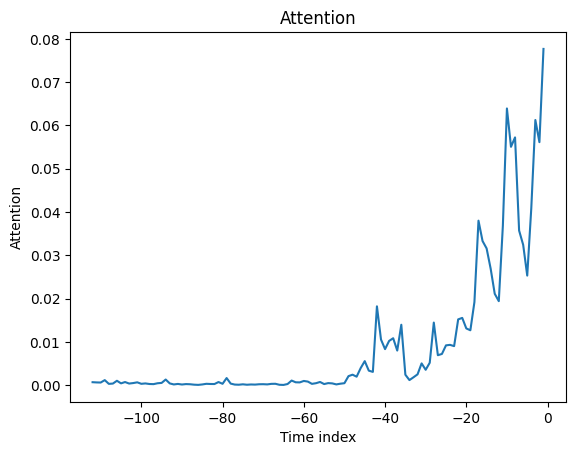

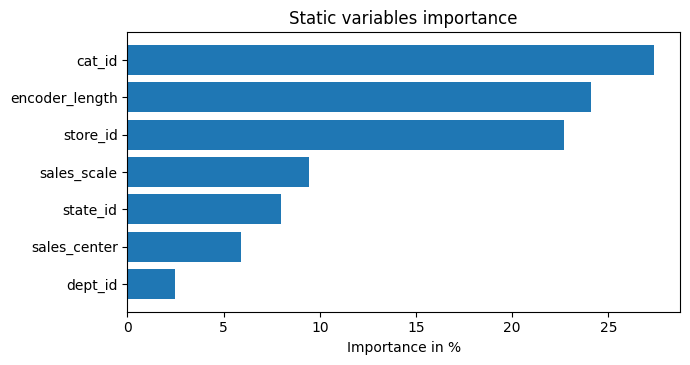

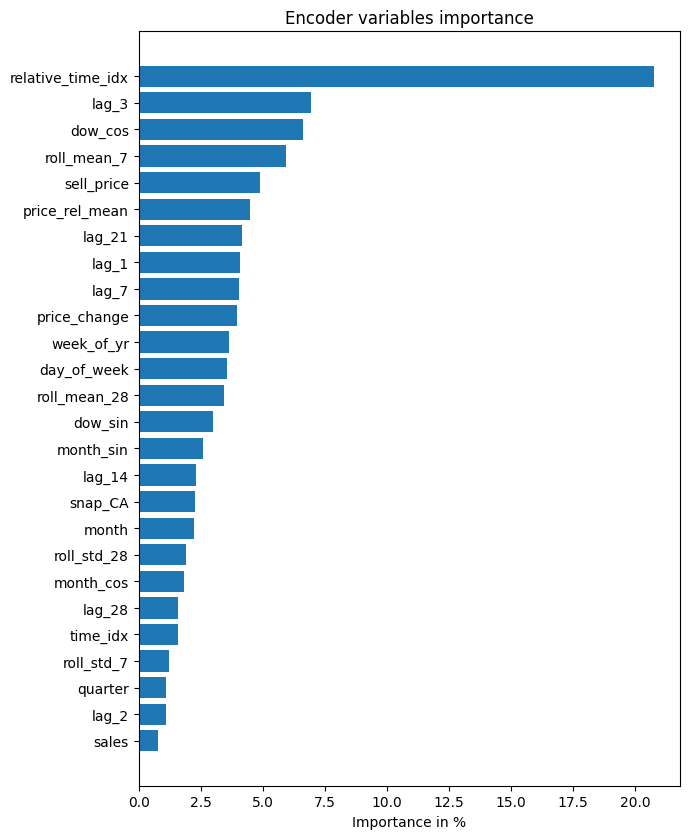

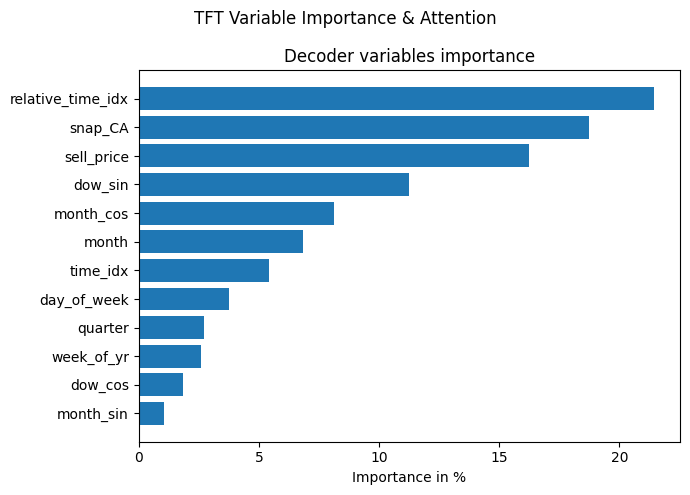

In [ ]:

# RAW OUTPUTS FOR INTERPRETATION


raw_output = best_tft.predict(
    val_loader,
    mode='raw'
)


# INTERPRET MODEL OUTPUT
 

interpretation = best_tft.interpret_output(
    raw_output,
    reduction='sum'
)

# 
# PLOT FEATURE IMPORTANCE


best_tft.plot_interpretation(
    interpretation
)

plt.suptitle(
    "TFT Variable Importance & Attention"
)

plt.tight_layout()
plt.show()